In [1]:
import networkx as nx
import pickle
import copy
import matplotlib.pyplot as plt
from epidemic_simulation.sir_simulation import fast_SIR
from epidemic_simulation.helpers import *
from sample.helpers import *
from sample.sampling_trees import TreeSampler
from sample.search_on_graphs import feasible_tree

In [2]:
#Loading our example of verification test
with open('data/graphs/verification_test_graph.pickle', mode='rb') as f:
    G = pickle.load(f)

In [3]:
beta = 0.4
fast_SIR(G, [0], beta)

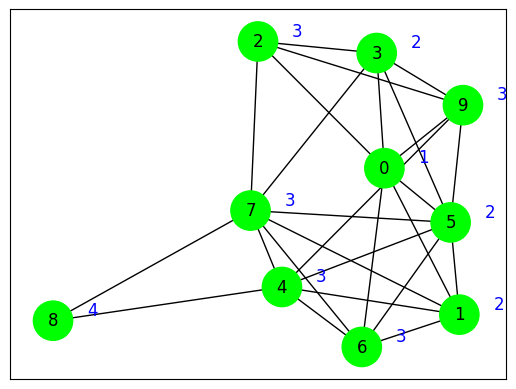

In [4]:
#Visualization of the graph with their respectives infection times
color_state_map = {'recovered': 'lime', 'susceptible': 'cyan'}
node_color = [color_state_map[node[1]['status']] for node in G.nodes(data=True)]

infection_times = nx.get_node_attributes(G, "inf_time")
pos = nx.spring_layout(G, seed = 0)
state_pos = {n: (x + 0.14, y + 0.05) for n, (x,y) in pos.items()}

nx.draw_networkx(G,
                pos,
                node_size = 800,
                node_color = node_color,)

nx.draw_networkx_labels(G, state_pos, labels= infection_times, font_color='blue')
plt.show()

In [5]:
#Making a copy with the real infection times
G_real = copy.deepcopy(G)

#Selecting a fraction of nodes that will not be observed.
p_excluded = 0.4
excluded, infected_nodes = excludeInfTime(G, p_excluded)

#Deleting nodes that we known were not infected from the graph.
delete_susceptibles(G)

In [6]:
T_initial = feasible_tree(G, infected_nodes, flag=1)
print(T_initial)

[[0], [1, 0], [2, 3], [3, 0], [6, 1], [7, 3]]


In [ ]:
if None in T_initial:
    print("Feasible tree not found!")

else:

    samplings_number = 10

    #Initialize class
    sampler = TreeSampler(G, T_initial, infected_nodes,flag=1)

    #Run
    sampling = sampler.run(n_iterations=samplings_number)
    print(f"Real infection times: {nx.get_node_attributes(G_real, "inf_time")}")
    print("--------------------------------------------------------------------------------------------")
    print(f"Frequency of nodes: {nodes_proportion(G, sampling)}")

Sampling trees:   0%|          | 0/500 [00:00<?, ?it/s]

Sampling trees:  10%|█         | 52/500 [00:00<00:01, 257.21it/s]

Tree statistics:
n_sucess: 5
n_fail: 0
Changing path
Current beta: 0.24923939897315536
Succes events: 5
Failed events: 12
prob_log: -10.38672843337404
Current beta: 0.24923939897315536
Succes events: 5
Failed events: 12
prob_log: -10.38672843337404
Current beta: 0.24923939897315536
Succes events: 5
Failed events: 12
prob_log: -10.38672843337404
Current beta: 0.24923939897315536
Succes events: 5
Failed events: 12
prob_log: -10.38672843337404

Current Tree: [[0], [1, 0], [2, 3], [3, 0], [6, 1], [7, 1]]

Nodes to sample: [0, 1, 2, 3, 6, 7]

Unobserved leaves: []

Current infection times: {0: 1, 1: 2, 2: 3, 3: 2, 4: inf, 5: inf, 6: 3, 7: 3, 8: inf, 9: inf}
Tree statistics:
n_sucess: 5
n_fail: 0
New node added: 5
Current beta: 0.18976633501702564
Succes events: 5
Failed events: 12
prob_log: -10.835000068375436
Current beta: 0.18976633501702564
Succes events: 6
Failed events: 9
prob_log: -11.865664054853788
Current beta: 0.18976633501702564
Succes events: 5
Failed events: 12
prob_log: -10.83

Sampling trees:  16%|█▌        | 78/500 [00:00<00:01, 239.10it/s]

Tree statistics:
n_sucess: 9
n_fail: 0
Current beta: 0.7017270103527853
Succes events: 9
Failed events: 0
prob_log: -3.187897422559329

Current Tree: [[0], [1, 0], [2, 3], [3, 0], [6, 1], [7, 1], [5, 7], [4, 6], [8, 4], [9, 3]]

Nodes to sample: [0, 1, 2, 3, 6, 7, 5, 4, 8, 9]

Unobserved leaves: [5, 8, 9]

Current infection times: {0: 1, 1: 2, 2: 3, 3: 2, 4: 4, 5: 4, 6: 3, 7: 3, 8: 5, 9: 3}
Tree statistics:
n_sucess: 9
n_fail: 0
Current beta: 0.6200653256227451
Succes events: 9
Failed events: 0
prob_log: -4.301373983271597

Current Tree: [[0], [1, 0], [2, 3], [3, 0], [6, 1], [7, 1], [5, 7], [4, 6], [8, 4], [9, 3]]

Nodes to sample: [0, 1, 2, 3, 6, 7, 5, 4, 8, 9]

Unobserved leaves: [5, 8, 9]

Current infection times: {0: 1, 1: 2, 2: 3, 3: 2, 4: 4, 5: 4, 6: 3, 7: 3, 8: 5, 9: 3}
Tree statistics:
n_sucess: 9
n_fail: 0
{'Node deleted: 8'}
Current beta: 0.6135580195700846
Succes events: 9
Failed events: 0
prob_log: -4.39632403088747
Current beta: 0.6135580195700846
Succes events: 8
Failed e

...

Tree statistics:
n_sucess: 9
n_fail: 0
Changing path
Current beta: 0.8353575041324857
Succes events: 9
Failed events: 0
prob_log: -1.6190594738919653
Current beta: 0.8353575041324857
Succes events: 9
Failed events: 0
prob_log: -1.6190594738919653
Current beta: 0.8353575041324857
Succes events: 9
Failed events: 0
prob_log: -1.6190594738919653
Current beta: 0.8353575041324857
Succes events: 9
Failed events: 0
prob_log: -1.6190594738919653

Current Tree: [[0], [1, 0], [2, 3], [3, 0], [6, 1], [7, 3], [5, 7], [4, 6], [8, 4], [9, 3]]

Nodes to sample: [0, 1, 2, 3, 6, 7, 5, 4, 8, 9]

Unobserved leaves: [5, 8, 9]

Current infection times: {0: 1, 1: 2, 2: 3, 3: 2, 4: 4, 5: 4, 6: 3, 7: 3, 8: 5, 9: 3}
Tree statistics:
n_sucess: 9
n_fail: 0
{'Node deleted: 8'}
Current beta: 0.6401353026062828
Succes events: 9
Failed events: 0
prob_log: -4.0146814318510415
Current beta: 0.6401353026062828
Succes events: 8
Failed events: 2
prob_log: -5.612660034702444
Current beta: 0.6401353026062828
Succes events: 

Sampling trees:  80%|████████  | 401/500 [00:01<00:00, 476.48it/s]

Current beta: 0.6319650475242063
Succes events: 9
Failed events: 0
prob_log: -4.130290718234451

Current Tree: [[0], [1, 0], [2, 3], [3, 0], [6, 1], [7, 3], [5, 7], [4], [6], [9, 5], [4, 5], [8, 4]]

Nodes to sample: [0, 1, 2, 3, 6, 7, 5, 9, 4, 8]

Unobserved leaves: [9, 8]

Current infection times: {0: 1, 1: 2, 2: 3, 3: 2, 4: 5, 5: 4, 6: 3, 7: 3, 8: 6, 9: 5}
Tree statistics:
n_sucess: 9
n_fail: 0
Current beta: 0.6944278334809364
Succes events: 9
Failed events: 0
prob_log: -3.282003302952992

Current Tree: [[0], [1, 0], [2, 3], [3, 0], [6, 1], [7, 3], [5, 7], [4], [6], [9, 5], [4, 5], [8, 4]]

Nodes to sample: [0, 1, 2, 3, 6, 7, 5, 9, 4, 8]

Unobserved leaves: [9, 8]

Current infection times: {0: 1, 1: 2, 2: 3, 3: 2, 4: 5, 5: 4, 6: 3, 7: 3, 8: 6, 9: 5}
Tree statistics:
n_sucess: 9
n_fail: 0
Changing path
Current beta: 0.5888553148208163
Succes events: 9
Failed events: 0
prob_log: -4.766172938746619
Current beta: 0.5888553148208163
Succes events: 9
Failed events: 0
prob_log: -4.76617293

Sampling trees: 100%|██████████| 500/500 [00:01<00:00, 367.81it/s]

Current beta: 0.6171528924210055
Succes events: 9
Failed events: 0
prob_log: -4.343746374577178

Current Tree: [[0], [1, 0], [2, 3], [3, 0], [6, 1], [7, 1], [5, 7], [4], [6], [9, 5], [4, 5], [8, 4]]

Nodes to sample: [0, 1, 2, 3, 6, 7, 5, 9, 4, 8]

Unobserved leaves: [9, 8]

Current infection times: {0: 1, 1: 2, 2: 3, 3: 2, 4: 5, 5: 4, 6: 3, 7: 3, 8: 6, 9: 5}
Tree statistics:
n_sucess: 9
n_fail: 0
{'Node deleted: 9'}
Current beta: 0.722712506947476
Succes events: 9
Failed events: 0
prob_log: -2.9226939748159566
Current beta: 0.722712506947476
Succes events: 8
Failed events: 5
prob_log: -9.01145234966101
Current beta: 0.722712506947476
Succes events: 9
Failed events: 0
prob_log: -2.9226939748159566

Current Tree: [[0], [1, 0], [2, 3], [3, 0], [6, 1], [7, 1], [5, 7], [4], [6], [9, 5], [4, 5], [8, 4]]

Nodes to sample: [0, 1, 2, 3, 6, 7, 5, 9, 4, 8]

Unobserved leaves: [9, 8]

Current infection times: {0: 1, 1: 2, 2: 3, 3: 2, 4: 5, 5: 4, 6: 3, 7: 3, 8: 6, 9: 5}
Tree statistics:
n_sucess: 

### Plots (visualizing results)
Trace plot

(The drops to low values (e.g., -40) is an indicator of bugs or an instability in the acceptance logic)

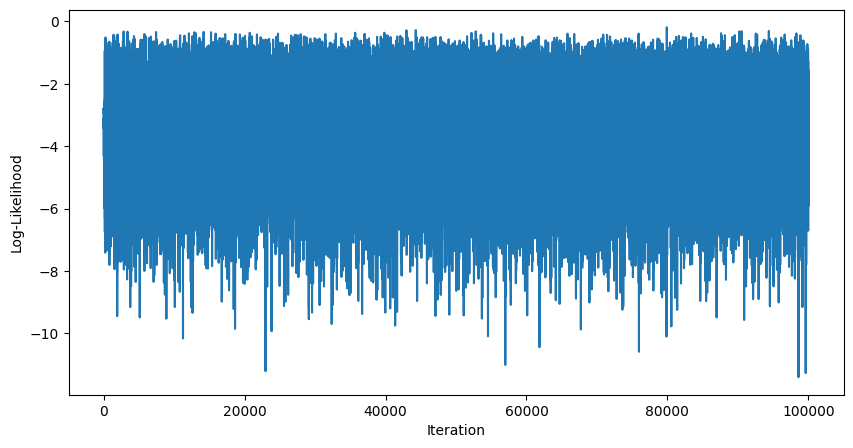

In [21]:
sampler._trace_plot_log_likelihood()